# Homework 3

## Import

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("course_lead_scoring_2026.csv")

## Explore the data

In [3]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [4]:
df.index

RangeIndex(start=0, stop=5000, step=1)

In [5]:
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [6]:
df.iloc[1000:1005]

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
1000,paid_ads,education,employed,africa,24475.0,4,6,0.56,0
1001,social_media,technology,employed,south_america,71772.0,2,4,0.43,0
1002,events,manufacturing,employed,africa,31153.0,0,4,0.35,0
1003,referral,healthcare,student,north_america,28049.0,2,5,0.60,0
1004,organic_search,finance,unemployed,north_america,61452.0,2,2,0.29,1


In [7]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [8]:
df.interaction_count.nunique()


14

In [9]:
df.number_of_courses_viewed.nunique()

7

### interaction_count and number_courses_viewed should be treated as categorical or not? I think it is better to treat them as numerical.

In [10]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [11]:
categorical = [s for s in df.columns.values if df[s].dtype == "str" ]
categorical

['lead_source', 'industry', 'employment_status', 'location']

In [12]:
numerical = [s for s in df.columns.values if df[s].dtype == "float64" or df[s].dtype == "int64" and s != "converted"]
numerical

['annual_income',
 'number_of_courses_viewed',
 'interaction_count',
 'lead_score']

## Preparation of data

In [13]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['lead_source', 'industry', 'employment_status', 'location',
       'annual_income', 'number_of_courses_viewed', 'interaction_count',
       'lead_score', 'converted'],
      dtype='str')

In [14]:
for s in categorical:
    df[s] = df[s].str.lower().str.replace(" ","_")

In [15]:
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [16]:
df.iloc[2000:2005]

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
2000,organic_search,technology,employed,asia,74795.0,4,10,0.91,1
2001,paid_ads,education,student,south_america,12000.0,1,3,0.26,0
2002,organic_search,NaN,NaN,south_america,61456.0,4,8,0.93,1
2003,organic_search,finance,employed,asia,65894.0,2,6,0.66,1
2004,paid_ads,education,employed,africa,34480.0,1,1,0.27,0


In [17]:
df.nunique()

lead_source                    5
industry                       6
employment_status              4
location                       5
annual_income               4313
number_of_courses_viewed       7
interaction_count             14
lead_score                    99
converted                      2
dtype: int64

In [18]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [19]:
df[categorical] = df[categorical].fillna("NA")
df[categorical].head(5)

,lead_source,industry,employment_status,location
0,organic_search,technology,employed,europe
1,social_media,technology,employed,south_america
2,referral,retail,employed,europe
3,paid_ads,manufacturing,student,NA
4,referral,manufacturing,student,north_america


In [20]:
df[categorical].iloc[1500:1505]

,lead_source,industry,employment_status,location
1500,organic_search,technology,unemployed,europe
1501,social_media,retail,employed,south_america
1502,paid_ads,NA,employed,asia
1503,organic_search,education,self_employed,africa
1504,referral,healthcare,employed,asia


In [21]:
df[numerical] = df[numerical].fillna(0)

In [22]:
df["converted"].isnull().sum()

np.int64(0)

## Question 1

In [23]:
df["industry"].mode()

0    technology
Name: industry, dtype: str

In [24]:
(df["industry"] == "technology").sum()

np.int64(1173)

### Answer to question 1: technology

## Question 2

In [25]:
corr_matrix = df[numerical].corr()
corr_matrix

,annual_income,number_of_courses_viewed,interaction_count,lead_score
annual_income,1.000000,0.161300,0.122842,0.229496
number_of_courses_viewed,0.161300,1.000000,0.721609,0.757204
interaction_count,0.122842,0.721609,1.000000,0.915746
lead_score,0.229496,0.757204,0.915746,1.000000


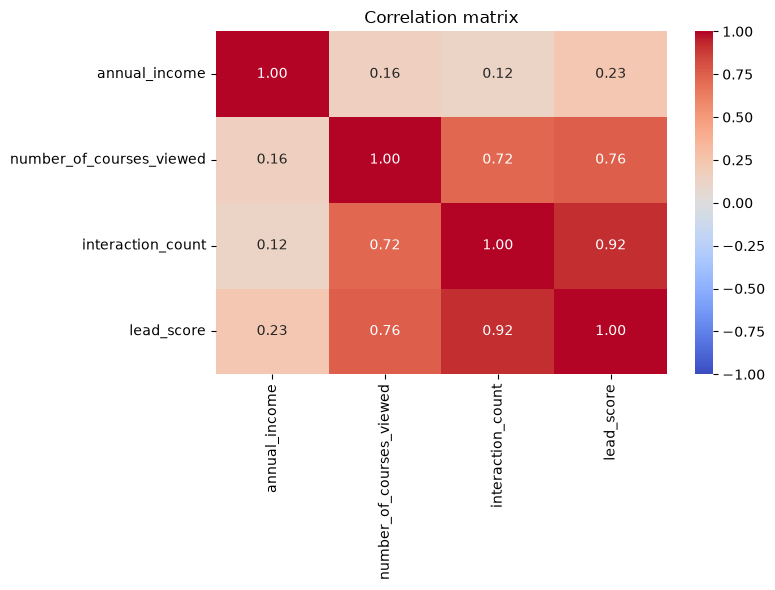

In [26]:

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,       # Display correlation values
    fmt=".2f",        # Two decimal places
    cmap="coolwarm",  # Blue = negative, red = positive
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

### Answer to question 2: interaction_count and lead_score

## Splitting up the dataset

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)

In [29]:
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [30]:
y_train = df_train["converted"].values
y_val = df_val["converted"].values
y_test = df_test["converted"].values

In [31]:
del df_train["converted"]
del df_val["converted"]
del df_test["converted"]

## Question 3

In [32]:
from sklearn.metrics import mutual_info_score

In [33]:
for i in categorical:
    s = mutual_info_score(df_train[i],y_train)
    print(f"{i}: {round(s,2)}")

lead_source: 0.03
industry: 0.0
employment_status: 0.02
location: 0.0


### Answer to question 3: lead_source

## Question 4

### One hot embedding

In [34]:
from sklearn.feature_extraction import DictVectorizer

dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

In [35]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

### Training models

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)

In [37]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [38]:
y_pred = model.predict_proba(X_val)[:, 1]

In [39]:
y_decision = (y_pred >= 0.5)

In [40]:
accuracy = (y_decision == y_val).mean()
accuracy

np.float64(0.645)

In [41]:
round((y_decision == y_val).mean(),2)

np.float64(0.64)

### Answer to question 4: 0.65

## Question 5

In [42]:
elimination = ["lead_source","number_of_courses_viewed", "interaction_count"]

In [43]:
for i in elimination:
    dv_rest = DictVectorizer(sparse=False)
    columns = categorical.copy()
    columns.extend(numerical)
    columns.remove(i)
    train_dict_rest = df_train[columns].to_dict(orient='records')
    X_train_rest = dv_rest.fit_transform(train_dict_rest)
    val_dict_rest = df_val[columns].to_dict(orient='records')
    X_val_rest = dv_rest.transform(val_dict_rest)
    model_rest = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model_rest.fit(X_train_rest, y_train)
    y_pred_rest = model_rest.predict_proba(X_val_rest)[:, 1]
    y_decision_rest = (y_pred_rest >= 0.5)
    accuracy_new = (y_decision_rest == y_val).mean()
    diff = accuracy - accuracy_new
    print(f"remove {i}: difference is {diff}")


remove lead_source: difference is 0.0030000000000000027
remove number_of_courses_viewed: difference is 0.0020000000000000018
remove interaction_count: difference is 0.04400000000000004


### Answer to question 5: number_of_courses_viewed

## Question 6

In [44]:
reg = [0.000001, 0.00001, 0.0001, 0.001]

In [46]:
for c in reg:
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_val)[:, 1]
    y_decision = (y_pred >= 0.5)
    accuracy = (y_decision == y_val).mean()
    print(f"{c}: {accuracy}")

    

1e-06: 0.598
1e-05: 0.598
0.0001: 0.613
0.001: 0.645


C = 0.001 leads to the best accuracy on the validation set